## Werkzeuge

In [33]:
from pandas import read_csv
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.cluster import KMeans

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

## Daten laden

In [34]:
data = read_csv(
    "../data/online_retail_data.csv",
    sep=";",
    skiprows=1,            # Erste Zeile überspringen
    decimal=",",           # Komma
    encoding="utf-8-sig", 
    on_bad_lines="skip",   # ERROR-Zeile überspringen
)
print(data.shape)
data.head()

(541910, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,01.12.10 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,01.12.10 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,01.12.10 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,01.12.10 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,01.12.10 08:26,3.39,17850.0,United Kingdom


## Daten explorieren

In [35]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541908 non-null  str    
 1   StockCode    541676 non-null  str    
 2   Description  540018 non-null  str    
 3   Quantity     541908 non-null  float64
 4   InvoiceDate  541908 non-null  str    
 5   UnitPrice    541908 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541908 non-null  str    
dtypes: float64(3), str(5)
memory usage: 33.1 MB


In [36]:
data.describe()

,Quantity,UnitPrice,CustomerID
count,541908.000000,541908.000000,406829.000000
mean,9.552262,4.611121,15287.690570
std,218.081359,96.759942,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Daten vorbereiten

Daten bereinigen

In [37]:
data = data.dropna(how="all")
data = data[data["InvoiceNo"].notna()]
data = data[~data["Country"].astype(str).str.strip().str.isdigit()]   # Country="0" rauslöschen
data = data[~data["InvoiceNo"].astype(str).str.startswith("C")]       # Storierte Rechungen rauslöschen
data = data[(data["Quantity"] > 0) & (data["UnitPrice"] > 0)]
data = data[data["CustomerID"].notna() & data["InvoiceDate"].notna()]
data["CustomerID"] = data["CustomerID"].astype(int)
data["TotalPrice"] = data["Quantity"] * data["UnitPrice"]

print(data.shape)
print("Eindeutige Kunden:", data["CustomerID"].nunique())

(397883, 9)
Eindeutige Kunden: 4338


Umsatz berechnen

In [38]:
data["LinePrice"] = data["Quantity"] * data["UnitPrice"]
data[["Quantity", "UnitPrice", "LinePrice"]].head()

,Quantity,UnitPrice,LinePrice
0,6.0,2.55,15.30
1,6.0,3.39,20.34
2,8.0,2.75,22.00
3,6.0,3.39,20.34
4,6.0,3.39,20.34


Umsatz pro Kunde und Revenue Zeile hinzufügen

In [39]:
revenue_df = data.groupby("CustomerID")["LinePrice"].sum().reset_index()
revenue_df = revenue_df.rename(columns={"LinePrice": "Revenue"})
print(revenue_df.shape)
revenue_df.head()

(4338, 2)


,CustomerID,Revenue
0,12346,77183.60
1,12347,4310.00
2,12348,1797.24
3,12349,1757.55
4,12350,334.40


Eine Zeille pro Kunde

In [40]:

kunden = data.groupby("CustomerID").agg(
    Revenue       =("LinePrice", "sum"),       # Gesamtumsatz je Kunde (= Zielwert)
    AnzahlArtikel =("StockCode", "nunique"),   # Anzahl verschiedener Produkte
    AnzahlKaeufe  =("InvoiceNo", "nunique"),   # Anzahl Bestellungen
    DurchschnPreis=("UnitPrice", "mean")       # mittlerer Artikelpreis
).reset_index()

print(kunden.shape)
kunden.head()

(4338, 5)


,CustomerID,Revenue,AnzahlArtikel,AnzahlKaeufe,DurchschnPreis
0,12346,77183.60,1,1,1.040000
1,12347,4310.00,103,7,2.644011
2,12348,1797.24,22,4,5.764839
3,12349,1757.55,73,1,8.289041
4,12350,334.40,17,1,3.841176


Daten vertikal Splitten

In [41]:
X = kunden[[
    "AnzahlArtikel",
    "AnzahlKaeufe",
    "DurchschnPreis"
]]

y = kunden["Revenue"]

Horizontal splitten

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(3470, 3) (3470,)
(868, 3) (868,)


Vorbereitungspipeline

In [43]:
numerical_cols = make_column_selector(dtype_include=["number"])
categorical_cols = make_column_selector(dtype_exclude=["number"])

numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)
print(X_train.shape, X_test.shape)

(3470, 3) (868, 3)


## Maschine Learning

### Decision Tree Regressor

In [44]:
tree_regressor = DecisionTreeRegressor(max_depth=3)
tree_regressor.fit(X_train, y_train)
tree_predictions = tree_regressor.predict(X_test)

In [45]:
print("Decision Tree R^2: ", r2_score(y_test, tree_predictions))
print("Decision Tree MAE: ", mean_absolute_error(y_test, tree_predictions))
print("Decision Tree RMSE:", root_mean_squared_error(y_test, tree_predictions))

Decision Tree R^2:  0.44676465814664157
Decision Tree MAE:  1600.5292167422879
Decision Tree RMSE: 7528.279692347124


### Lineare Regression

In [46]:
linear_regressor = LinearRegression()
linear_regressor.fit(X_train, y_train)
linear_predictions = linear_regressor.predict(X_test)

In [47]:
print("Linear Regression R^2: ", r2_score(y_test, linear_predictions))
print("Linear Regression MAE: ", mean_absolute_error(y_test, linear_predictions))
print("Linear Regression RMSE:", root_mean_squared_error(y_test, linear_predictions))

Linear Regression R^2:  0.3238015871060834
Linear Regression MAE:  1520.1485023839498
Linear Regression RMSE: 8322.961032146504


### Overfitting-Check: Train vs. Test

In [50]:
# Decision Tree: Vorhersagen auch auf den Trainingsdaten
tree_train_predictions = tree_regressor.predict(X_train)

print("--- Decision Tree ---")
print("Train R^2:", r2_score(y_train, tree_train_predictions))
print("Test  R^2:", r2_score(y_test, tree_predictions))
print()

# Lineare Regression: dasselbe
linear_train_predictions = linear_regressor.predict(X_train)

print("--- Lineare Regression ---")
print("Train R^2:", r2_score(y_train, linear_train_predictions))
print("Test  R^2:", r2_score(y_test, linear_predictions))

--- Decision Tree ---
Train R^2: 0.5613852147463277
Test  R^2: 0.44676465814664157

--- Lineare Regression ---
Train R^2: 0.29712693188534367
Test  R^2: 0.3238015871060834


### Vorhersagen visualisieren

Wir tragen die echten Umsätze (x-Achse) gegen die vorhergesagten Umsätze (y-Achse) auf. Läge das Modell perfekt, lägen alle Punkte auf der gestrichelten Linie.

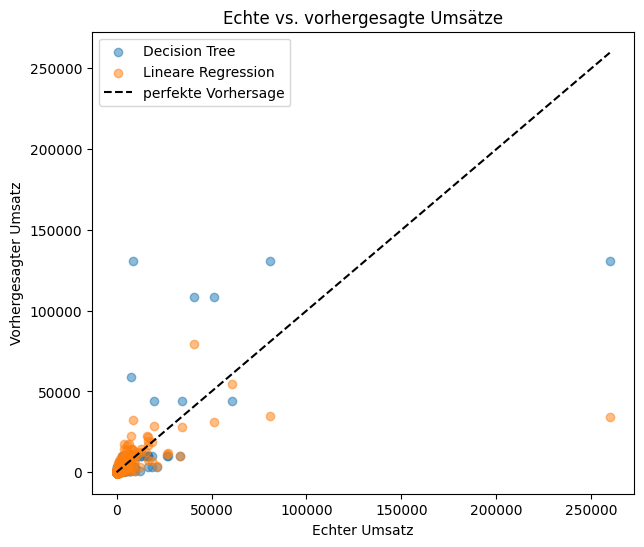

In [51]:
plt.figure(figsize=(7, 6))

# echte vs. vorhergesagte Werte für beide Modelle
plt.scatter(y_test, tree_predictions, alpha=0.5, label="Decision Tree")
plt.scatter(y_test, linear_predictions, alpha=0.5, label="Lineare Regression")

# Hilfslinie: perfekte Vorhersage (y = x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", label="perfekte Vorhersage")

plt.xlabel("Echter Umsatz")
plt.ylabel("Vorhergesagter Umsatz")
plt.title("Echte vs. vorhergesagte Umsätze")
plt.legend()
plt.show()

## Machine Learning Klassifikation

### Zielvariable bilden

Der Schwellenwert ist das 84,5%-Quantil des Umsatzes. Kunden darüber gelten als wertvoll (1), der Rest als normal (0).

In [52]:
schwelle = kunden["Revenue"].quantile(0.845)
kunden["WertvollerKunde"] = (kunden["Revenue"] > schwelle).astype(int)

print("Schwellenwert (GBP):", round(schwelle, 2))
print(kunden["WertvollerKunde"].value_counts())
print((kunden["WertvollerKunde"].value_counts(normalize=True) * 100).round(1))

Schwellenwert (GBP): 2605.8
WertvollerKunde
0    3665
1     673
Name: count, dtype: int64
WertvollerKunde
0    84.5
1    15.5
Name: proportion, dtype: float64


### Daten vertikal splitten (Input/Output)

Wichtig: Revenue darf kein Feature sein, da unsere Zielvariable direkt daraus berechnet wurde (das wäre ein Datenleck). Wir verwenden dieselben Merkmale wie bei der Regression.

In [53]:
X_clf = kunden[[
    "AnzahlArtikel",
    "AnzahlKaeufe",
    "DurchschnPreis"
]]

y_clf = kunden["WertvollerKunde"]

### Daten horizontal splitten (Train/Test)

In [54]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42)

### Vorverarbeitungspipeline

In [55]:
numerical_cols_clf = make_column_selector(dtype_include=["number"])

numerical_transformer_clf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

preprocessor_clf = ColumnTransformer(transformers=[
    ("num", numerical_transformer_clf, numerical_cols_clf)
])

X_train_clf = preprocessor_clf.fit_transform(X_train_clf)
X_test_clf = preprocessor_clf.transform(X_test_clf)

### Decision Tree Classifier

In [56]:
tree_classifier = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=3
)

tree_classifier.fit(X_train_clf, y_train_clf)

print("F1",        f1_score(y_test_clf, tree_classifier.predict(X_test_clf)))
print("Recall",    recall_score(y_test_clf, tree_classifier.predict(X_test_clf)))
print("Precision", precision_score(y_test_clf, tree_classifier.predict(X_test_clf)))
print("Accuracy",  accuracy_score(y_test_clf, tree_classifier.predict(X_test_clf)))

F1 0.7175572519083969
Recall 0.6861313868613139
Precision 0.752
Accuracy 0.9147465437788018


### K-Nearest-Neighbors Classifier

In [57]:
knn_classifier = KNeighborsClassifier(
    n_neighbors=9
)

knn_classifier.fit(X_train_clf, y_train_clf)

print("F1",        f1_score(y_test_clf, knn_classifier.predict(X_test_clf)))
print("Recall",    recall_score(y_test_clf, knn_classifier.predict(X_test_clf)))
print("Precision", precision_score(y_test_clf, knn_classifier.predict(X_test_clf)))
print("Accuracy",  accuracy_score(y_test_clf, knn_classifier.predict(X_test_clf)))

F1 0.6923076923076923
Recall 0.656934306569343
Precision 0.7317073170731707
Accuracy 0.9078341013824884
